# Phase 1: Exploratory Data Analysis (EDA) - India Dataset
In this phase, we conduct a deep dive into the engineered India dataset. We will explore how regional climate variables, seasonal anomalies, and historical momentum influence wheat productivity across different Indian states and districts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the moderate version 2 dataset
file_path = '/content/drive/MyDrive/wheat_yield_india/dataset/final_india_wheat_dataset_moderate_v2.csv'
df_india = pd.read_csv(file_path)

# 3. Initial Inspection
print("Dataset Shape:", df_india.shape)
print("\nFirst 5 Rows:")
display(df_india.head())

Mounted at /content/drive
Dataset Shape: (4002, 24)

First 5 Rows:


,Country,State,Dist Code,District,Year,Yield,Avg_Season_Tmax,Total_Season_Rain,Sowing_Rainfall,Terminal_Heat_Tmax,...,Yield_Rolling_Std3,Avg_Season_Tmax_Anomaly,Total_Season_Rain_Anomaly,Sowing_Rainfall_Anomaly,Terminal_Heat_Tmax_Anomaly,Temperature_Anomaly_Anomaly,Rainfall_Deviation_Anomaly,Terminal_vs_AvgTemp,SowingRain_to_TotalRain,Rain_per_Temp
0,India,Madhya Pradesh,7,Jabalpur,1995,1219.02,28.498343,87.7,0.3,33.719672,...,0.000000,-0.981717,25.247826,-25.982609,-1.640413,-0.981717,25.247826,5.221330,0.003382,3.077372
1,India,Madhya Pradesh,7,Jabalpur,1996,1154.65,29.592308,62.1,12.9,35.796721,...,45.516464,0.112248,-0.352174,-13.382609,0.436636,0.112248,-0.352174,6.204414,0.204437,2.098518
2,India,Madhya Pradesh,7,Jabalpur,1997,910.12,28.898343,15.7,5.8,34.272131,...,162.971177,-0.581717,-46.752174,-20.482609,-1.087954,-0.581717,-46.752174,5.373789,0.347305,0.543284
3,India,Madhya Pradesh,7,Jabalpur,1998,732.53,26.983425,283.5,272.7,34.009836,...,211.942769,-2.496635,221.047826,246.417391,-1.350249,-2.496635,221.047826,7.026411,0.958524,10.506449
4,India,Madhya Pradesh,7,Jabalpur,1999,1344.30,29.211602,101.5,41.9,36.600000,...,314.725545,-0.268458,39.047826,15.617391,1.239914,-0.268458,39.047826,7.388398,0.408780,3.474647


### Statistical Overview & Data Integrity
We verify the integrity of our engineered features, specifically checking for any null values introduced during the rolling mean calculations. We also observe the statistical spread of India-specific climate features like `Sowing_Rainfall` and `Terminal_Heat_Tmax`.

In [2]:
# Statistical summary
numerical_cols = ['Yield', 'Yield_Lag2', 'Yield_Rolling_Mean3', 'Avg_Season_Tmax',
                  'Total_Season_Rain', 'Sowing_Rainfall', 'Terminal_Heat_Tmax',
                  'Temperature_Anomaly', 'Rainfall_Deviation']

print("Statistical Summary for India:")
display(df_india[numerical_cols].describe().round(2))

# Missing values check
print("\nMissing Values:")
print(df_india.isnull().sum()[df_india.isnull().sum() > 0])

Statistical Summary for India:


,Yield,Yield_Lag2,Yield_Rolling_Mean3,Avg_Season_Tmax,Total_Season_Rain,Sowing_Rainfall,Terminal_Heat_Tmax,Temperature_Anomaly,Rainfall_Deviation
count,4002.00,4002.00,4002.00,4002.00,4002.0,4002.00,4002.00,4002.00,4002.00
mean,2587.42,2521.13,2543.49,26.90,101.9,17.51,32.87,0.05,-3.11
std,999.18,967.28,940.63,4.53,125.0,37.40,5.27,0.94,63.73
min,0.00,0.00,525.62,13.03,0.0,0.00,15.93,-2.47,-216.06
25%,1837.38,1801.75,1828.84,26.49,21.4,0.30,32.58,-0.54,-35.58
50%,2532.55,2476.76,2490.31,28.01,59.2,3.80,34.43,0.10,-14.96
75%,3245.41,3143.47,3130.52,29.29,124.3,15.10,35.72,0.70,30.51
max,5541.52,5541.52,5326.40,32.87,634.2,272.70,38.93,2.39,229.31



Missing Values:
Series([], dtype: int64)


### Distribution of Indian Wheat Yield
Wheat yields in India can vary significantly between the high-productivity "Green Revolution" belt and other regions. This histogram visualizes the density and spread of productivity (Kg/Ha).

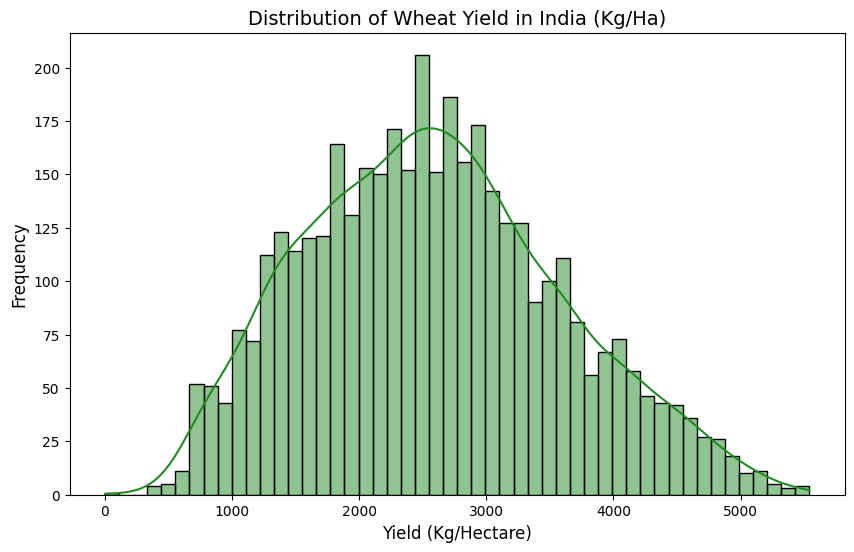

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df_india['Yield'], bins=50, kde=True, color='forestgreen')
plt.title('Distribution of Wheat Yield in India (Kg/Ha)', fontsize=14)
plt.xlabel('Yield (Kg/Hectare)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### Feature Correlation: Climate vs. Biological Momentum
We analyze how strongly our weather features correlate with the final yield. In the Indian context, we expect `Yield_Rolling_Mean3` to show high correlation, representing the established irrigation infrastructure of specific districts.



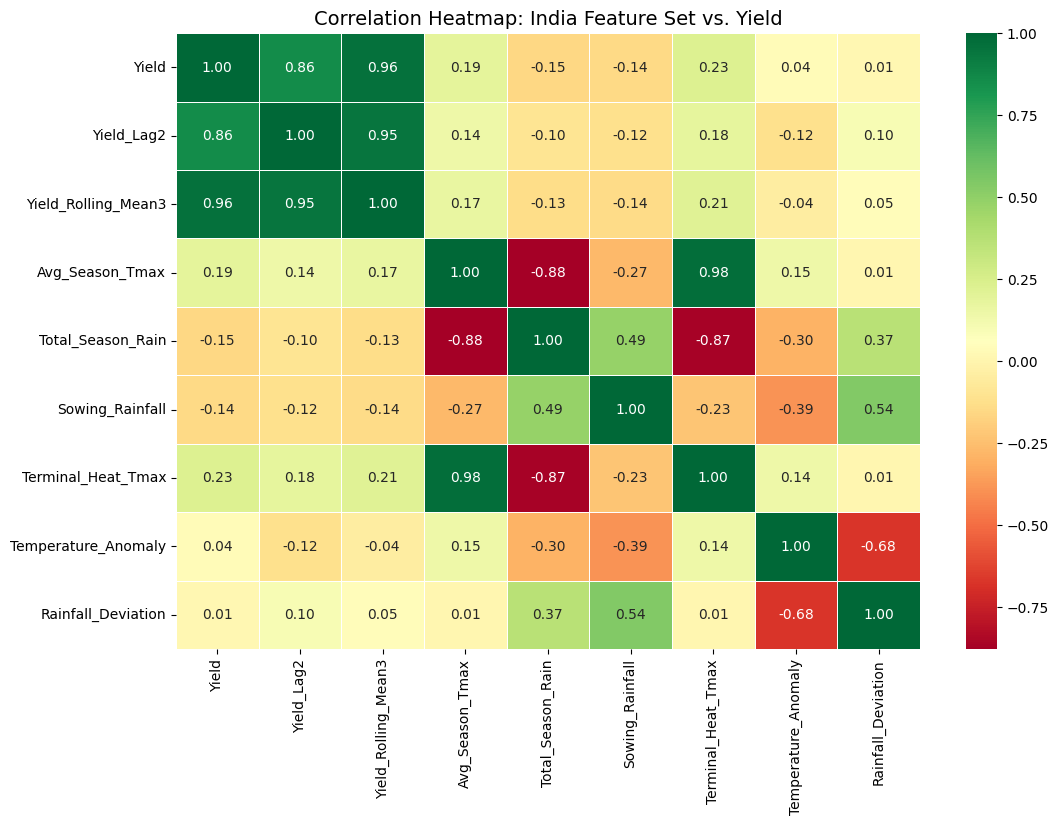

In [4]:
plt.figure(figsize=(12, 8))
corr_matrix = df_india[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: India Feature Set vs. Yield', fontsize=14)
plt.show()

### Macro Trends and Climate Deviations
We observe the historical trajectory of Indian wheat yields. Additionally, we plot the distribution of `Temperature_Anomaly` and `Rainfall_Deviation` to understand how frequently Indian districts face "shocks" compared to their local historical norms.

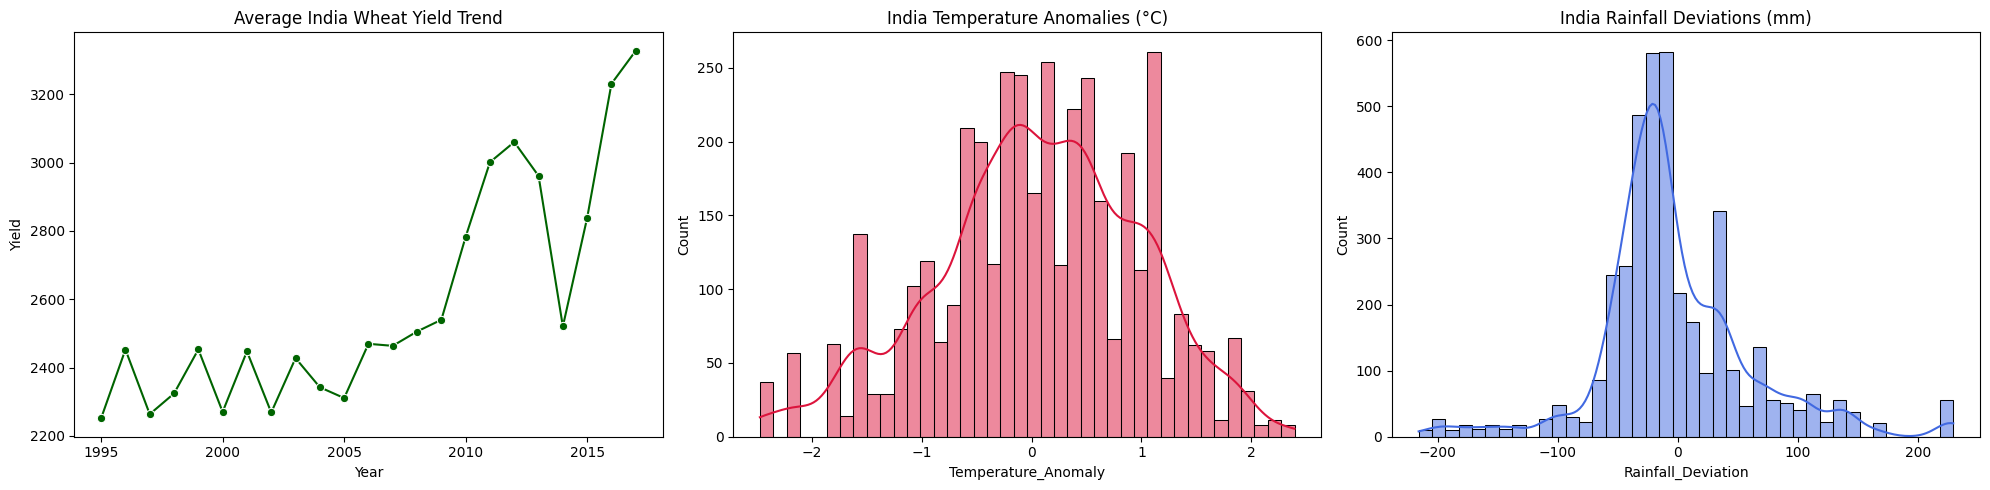

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Yield Trend
yearly_yield = df_india.groupby('Year')['Yield'].mean().reset_index()
sns.lineplot(data=yearly_yield, x='Year', y='Yield', marker='o', color='darkgreen', ax=axes[0])
axes[0].set_title('Average India Wheat Yield Trend', fontsize=12)

# Plot 2: Temperature Anomaly
sns.histplot(df_india['Temperature_Anomaly'], bins=40, kde=True, color='crimson', ax=axes[1])
axes[1].set_title('India Temperature Anomalies (°C)', fontsize=12)

# Plot 3: Rainfall Deviation
sns.histplot(df_india['Rainfall_Deviation'], bins=40, kde=True, color='royalblue', ax=axes[2])
axes[2].set_title('India Rainfall Deviations (mm)', fontsize=12)

plt.tight_layout()
plt.show()

### State-Wise Productivity Ranking
India's "breadbasket" states show distinct yield characteristics. This boxplot ranks states by their median yield, highlighting the performance gap between regions with advanced irrigation and those dependent on seasonal rainfall.

/tmp/ipykernel_245/335004138.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_india, x='State', y='Yield', order=sorted_states, palette='terrain')


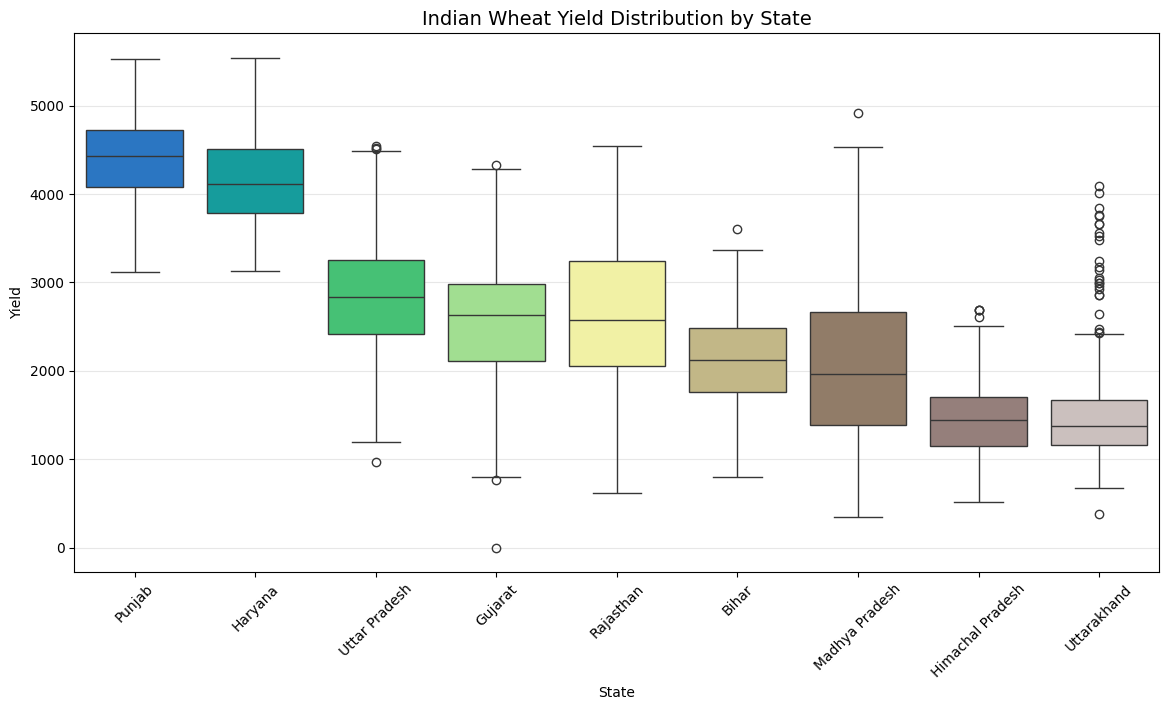

In [6]:
plt.figure(figsize=(14, 7))
sorted_states = df_india.groupby('State')['Yield'].median().sort_values(ascending=False).index

sns.boxplot(data=df_india, x='State', y='Yield', order=sorted_states, palette='terrain')
plt.title('Indian Wheat Yield Distribution by State', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Terminal Heat Stress: A Major Risk Factor
Terminal heat stress during the reproductive phase is a significant threat to Indian wheat. This regression plot illustrates the sensitivity of yield to high temperatures in the final stages of the growing season.

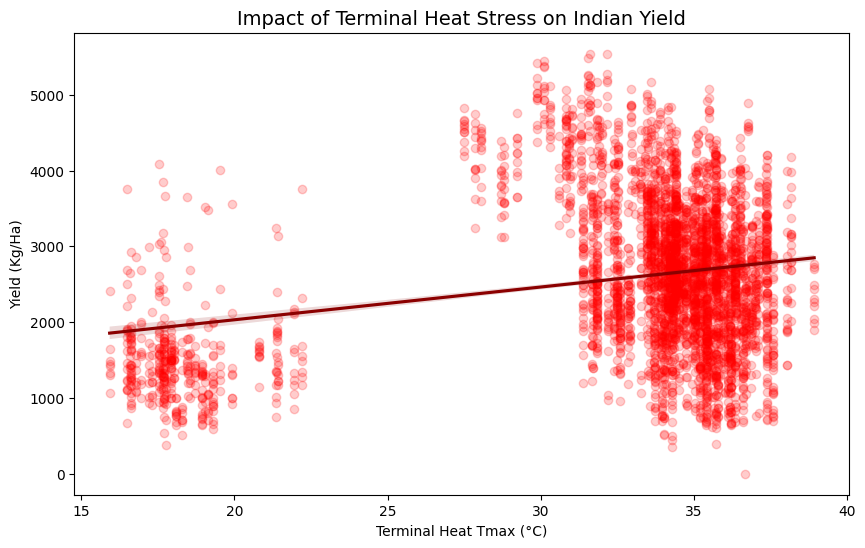

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_india, x='Terminal_Heat_Tmax', y='Yield',
            scatter_kws={'alpha':0.2, 'color': 'red'},
            line_kws={'color': 'darkred'})
plt.title('Impact of Terminal Heat Stress on Indian Yield', fontsize=14)
plt.xlabel('Terminal Heat Tmax (°C)')
plt.ylabel('Yield (Kg/Ha)')
plt.show()

### Quantifying Temperature Shocks
We categorize our `Temperature_Anomaly` feature to compare the average yield during "Normal" years versus years experiencing a significant "Hot Shock" (Anomalies > 1.0°C).

/tmp/ipykernel_245/2702008220.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_india, x='Temp_Status', y='Yield', order=categories, palette='autumn')


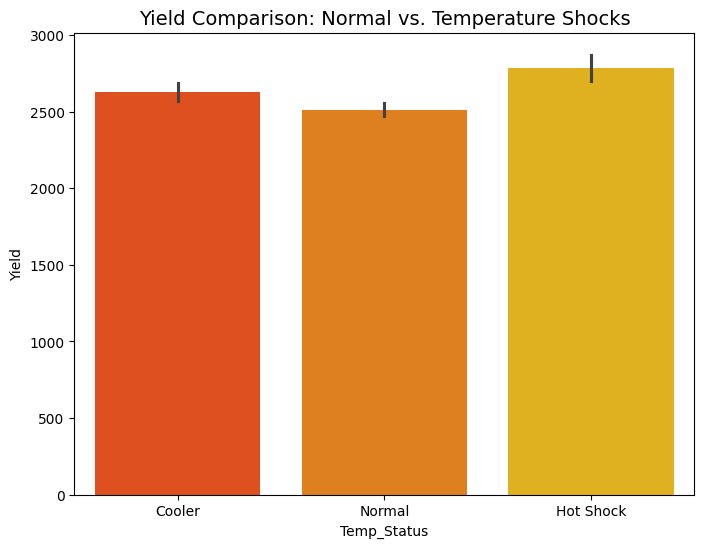

In [8]:
conditions = [
    (df_india['Temperature_Anomaly'] < -0.5),
    (df_india['Temperature_Anomaly'] >= -0.5) & (df_india['Temperature_Anomaly'] <= 1.0),
    (df_india['Temperature_Anomaly'] > 1.0)
]
categories = ['Cooler', 'Normal', 'Hot Shock']
df_india['Temp_Status'] = np.select(conditions, categories, default='Normal')

plt.figure(figsize=(8, 6))
sns.barplot(data=df_india, x='Temp_Status', y='Yield', order=categories, palette='autumn')
plt.title('Yield Comparison: Normal vs. Temperature Shocks', fontsize=14)
plt.show()

### Rainfall Deviations: Droughts vs. Surplus
Wheat is a rabi crop in India. We analyze how deviations from the mean rainfall impact the yield, distinguishing between moisture deficits (drought) and excess rainfall.

/tmp/ipykernel_245/1131560701.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_india, x='Rain_Status', y='Yield', order=labels_r, palette='YlGnBu')


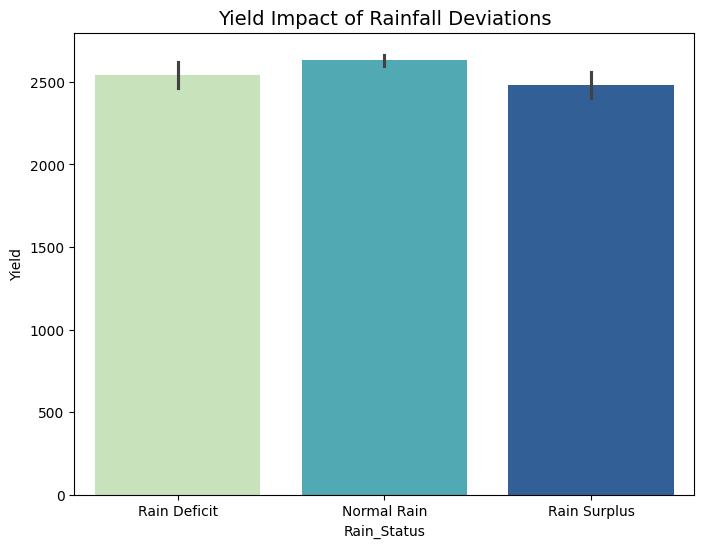

In [9]:
conditions_r = [
    (df_india['Rainfall_Deviation'] < -40),
    (df_india['Rainfall_Deviation'] >= -40) & (df_india['Rainfall_Deviation'] <= 40),
    (df_india['Rainfall_Deviation'] > 40)
]
labels_r = ['Rain Deficit', 'Normal Rain', 'Rain Surplus']
df_india['Rain_Status'] = np.select(conditions_r, labels_r, default='Normal')

plt.figure(figsize=(8, 6))
sns.barplot(data=df_india, x='Rain_Status', y='Yield', order=labels_r, palette='YlGnBu')
plt.title('Yield Impact of Rainfall Deviations', fontsize=14)
plt.show()

### Historical Persistence (Yield Momentum)
This plot confirms the "momentum" of agricultural productivity by comparing the current yield to the 3-year rolling mean. A strong linear trend indicates that localized factors (soil health, farming practices) remain consistent over short periods.

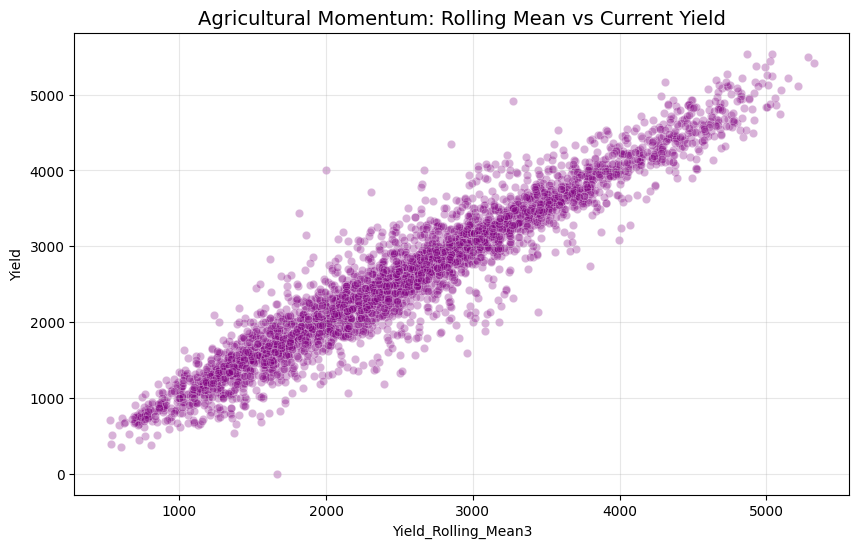

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_india, x='Yield_Rolling_Mean3', y='Yield', alpha=0.3, color='purple')
plt.title('Agricultural Momentum: Rolling Mean vs Current Yield', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### Sowing Period Rainfall Sensitivity
The initial moisture during the sowing window is critical for crop establishment. We visualize how `Sowing_Rainfall` correlates with the final harvest results.

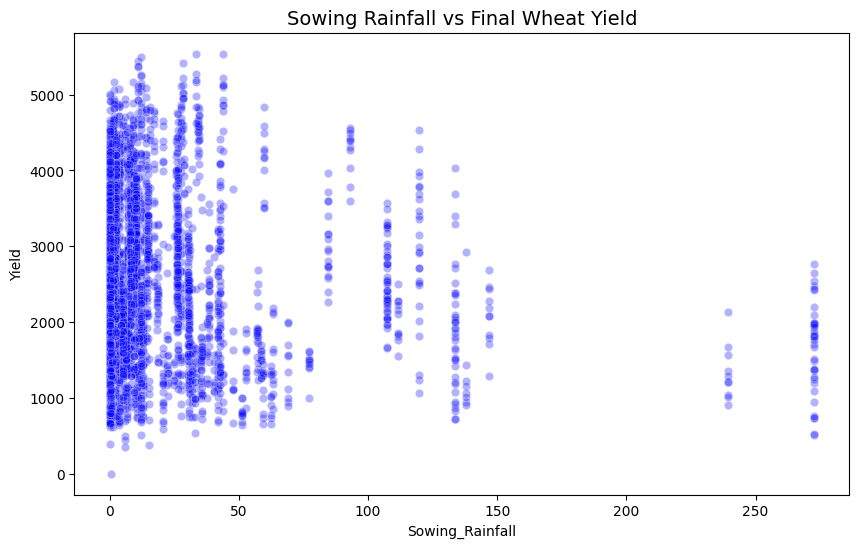

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_india, x='Sowing_Rainfall', y='Yield', alpha=0.3, color='blue')
plt.title('Sowing Rainfall vs Final Wheat Yield', fontsize=14)
plt.show()

### Top 10 Most Productive Districts
We identify the leading districts in India based on historical wheat yield averages. These districts likely represent the regions with the most stable irrigation and advanced agricultural technology.

/tmp/ipykernel_245/3332703814.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_dist.values, y=top_10_dist.index, palette='rocket')


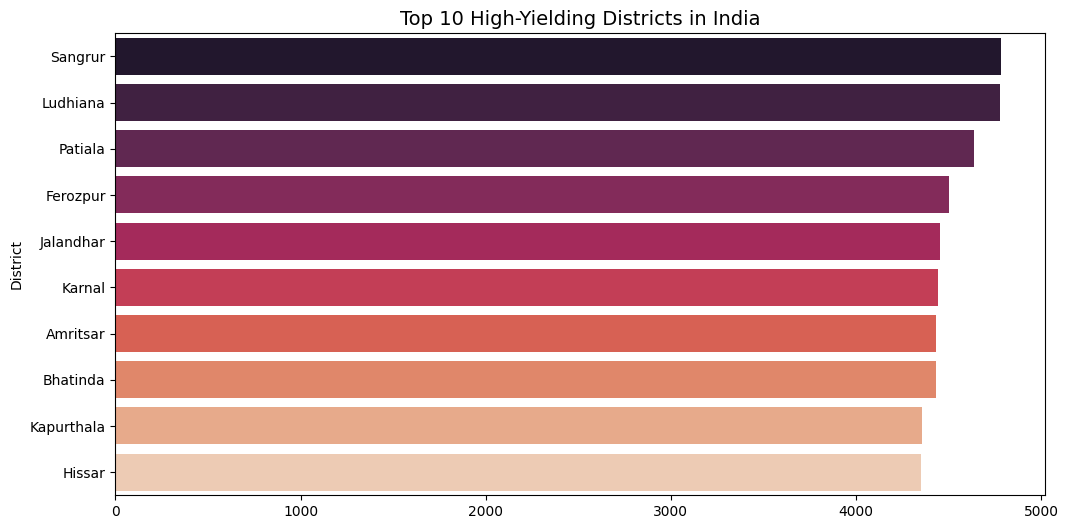

In [12]:
plt.figure(figsize=(12, 6))
top_10_dist = df_india.groupby('District')['Yield'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_dist.values, y=top_10_dist.index, palette='rocket')
plt.title('Top 10 High-Yielding Districts in India', fontsize=14)
plt.show()

### Yield Volatility Analysis (Risk Mapping)
By measuring the Standard Deviation of yield across states, we can identify which regions are "stable" and which are "high-risk." High volatility indicates states most vulnerable to climate fluctuations.

/tmp/ipykernel_245/3941329363.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volatility.index, y=volatility.values, palette='coolwarm')


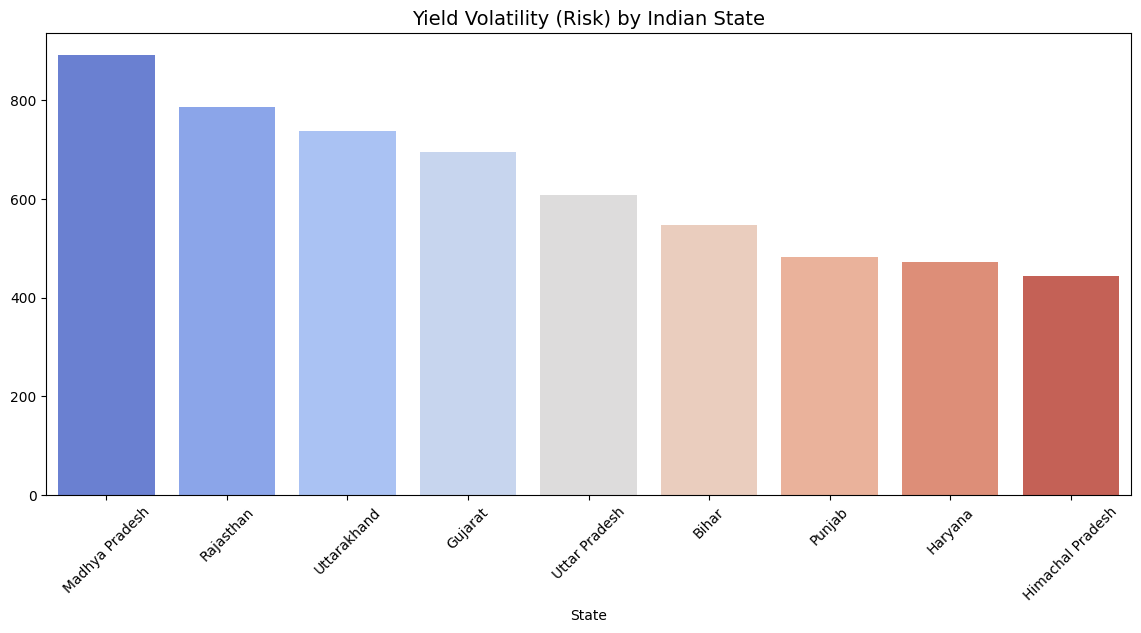

In [13]:
plt.figure(figsize=(14, 6))
volatility = df_india.groupby('State')['Yield'].std().sort_values(ascending=False)
sns.barplot(x=volatility.index, y=volatility.values, palette='coolwarm')
plt.title('Yield Volatility (Risk) by Indian State', fontsize=14)
plt.xticks(rotation=45)
plt.show()

### Progress Across Eras
We group the data into decadal "Eras" to visualize the overall growth in Indian agricultural productivity resulting from policy shifts and technological advancements.

/tmp/ipykernel_245/1883989660.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_india, x='Decade', y='Yield', palette='Pastel1')


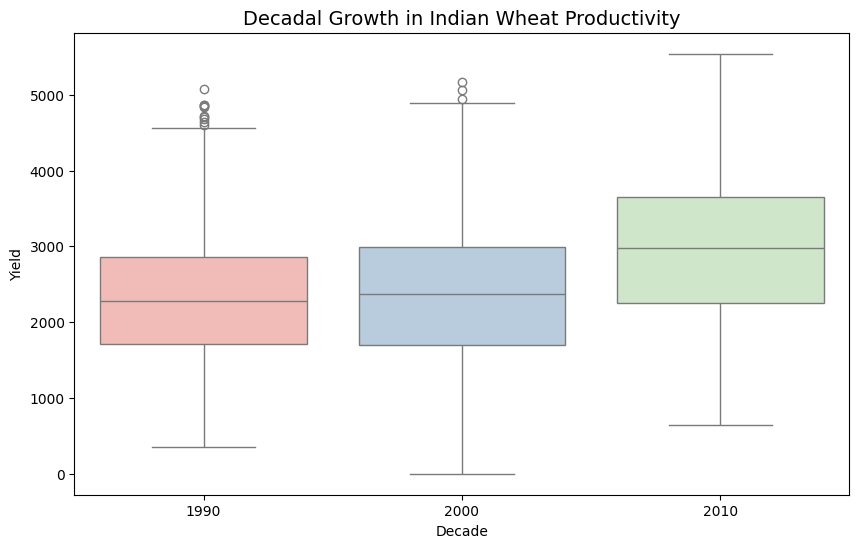

In [14]:
df_india['Decade'] = (df_india['Year'] // 10) * 10
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_india, x='Decade', y='Yield', palette='Pastel1')
plt.title('Decadal Growth in Indian Wheat Productivity', fontsize=14)
plt.show()

### The Climate Sweet Spot (Hexbin Map)
This density map (Hexbin) visualizes the "sweet spot" of temperature and rainfall where the vast majority of Indian wheat is successfully produced.

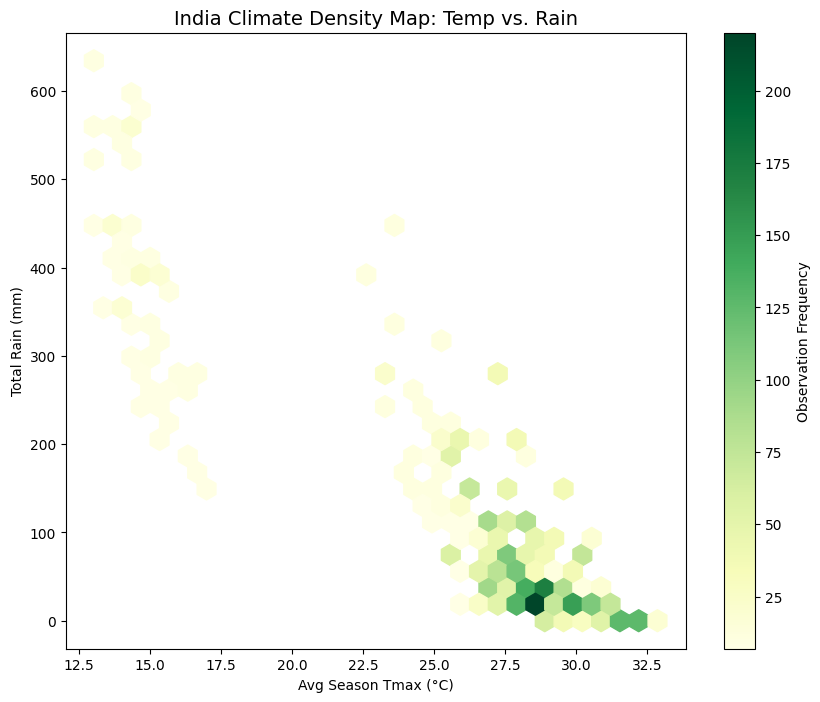

In [15]:
plt.figure(figsize=(10, 8))
plt.hexbin(df_india['Avg_Season_Tmax'], df_india['Total_Season_Rain'],
           gridsize=30, cmap='YlGn', mincnt=1)
plt.colorbar(label='Observation Frequency')
plt.title('India Climate Density Map: Temp vs. Rain', fontsize=14)
plt.xlabel('Avg Season Tmax (°C)')
plt.ylabel('Total Rain (mm)')
plt.show()

# Final clean up of temporary columns
df_india.drop(['Temp_Status', 'Rain_Status', 'Decade'], axis=1, inplace=True, errors='ignore')